# 02 — Model Training and Evaluation

Loads the synthetic dataset produced by `01_generate_dataset.ipynb`, trains a simple
CNN for bounding-box regression using **`HungarianLoss`** as the training objective,
and evaluates the trained model on the held-out test split.

> **Pre-requisite:** run `01_generate_dataset.ipynb` first so that `notebooks/data/`
> contains `train.npz`, `val.npz`, and `test.npz`.

In [31]:
%pip install matplotlib --quiet
import sys, os

project_root = (
    os.path.abspath('..')
    if os.path.basename(os.getcwd()) == 'notebooks'
    else os.path.abspath('.')
)
if project_root not in sys.path:
    sys.path.insert(0, project_root)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from hungarian_loss.loss import HungarianLoss, compute_euclidean_distance

tf.random.set_seed(42)
np.random.seed(42)

In [33]:
# ── configuration ──────────────────────────────────────────────────────────
IMG_SIZE   = 64
MAX_OBJ    = 3
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 3e-4

_nb_dir   = (
    os.path.join(os.getcwd(), 'notebooks')
    if os.path.isdir(os.path.join(os.getcwd(), 'notebooks'))
    else os.getcwd()
)
DATA_DIR  = os.path.join(_nb_dir, 'data')
MODEL_DIR = os.path.join(_nb_dir, 'models')
# ───────────────────────────────────────────────────────────────────────────


## 1. Load Dataset

In [34]:
def load_split(name):
    d = np.load(os.path.join(DATA_DIR, f'{name}.npz'))
    return d['images'], d['labels']


X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
X_test,  y_test  = load_split('test')

print(f'Train : {X_train.shape}  labels {y_train.shape}')
print(f'Val   : {X_val.shape}  labels {y_val.shape}')
print(f'Test  : {X_test.shape}  labels {y_test.shape}')

Train : (4200, 64, 64, 1)  labels (4200, 3, 4)
Val   : (900, 64, 64, 1)  labels (900, 3, 4)
Test  : (900, 64, 64, 1)  labels (900, 3, 4)


## 2. Model

A compact CNN encoder followed by a dense head that directly regresses all
`MAX_OBJ × 4` box coordinates.  The `sigmoid` activation keeps outputs in `[0, 1]`,
matching the normalised label range.

In [35]:
@tf.keras.utils.register_keras_serializable(package='hungarian_loss')
class LearnedQueries(tf.keras.layers.Layer):
    """Fixed learned object query embeddings, one per detection slot.

    Unlike the original GAP-derived queries, these are image-independent
    and each slot can specialise to a different spatial "role" during training.
    """
    def __init__(self, num_queries, d_model, **kwargs):
        super().__init__(**kwargs)
        self.num_queries = num_queries
        self.d_model = d_model

    def build(self, input_shape):
        self.queries = self.add_weight(
            name='object_queries',
            shape=(self.num_queries, self.d_model),
            initializer='glorot_uniform',
            trainable=True,
        )

    def call(self, x):
        # x is the encoder output — only used to read batch size
        batch = tf.shape(x)[0]
        return tf.tile(self.queries[None], [batch, 1, 1])

    def get_config(self):
        config = super().get_config()
        config.update({'num_queries': self.num_queries, 'd_model': self.d_model})
        return config


def _sinusoidal_pos_enc(seq_len, d_model):
    """Fixed 1D sinusoidal positional encoding, shape (1, seq_len, d_model).

    Without this, self-attention has no notion of WHERE each spatial token
    sits in the image — making accurate (x, y) prediction much harder.
    """
    pos    = np.arange(seq_len)[:, None]
    i      = np.arange(d_model)[None, :]
    angles = pos / np.power(10000, (2 * (i // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.constant(angles[None], dtype=tf.float32)   # (1, seq_len, d_model)


def build_detector(img_size=64, max_obj=3, d_model=128, n_heads=4,
                   n_enc_layers=3, ffn_dim=256):
    """
    DETR-lite object detector.

    Key design choices borrowed from DETR:
      * Labels in centre format [cx, cy, w, h] — easier target for attention.
      * Sinusoidal positional encoding on spatial tokens — attention knows
        WHERE each token is, critical for accurate coordinate regression.
      * Learnable object queries — each slot independently specialises to
        a different spatial role during training (no image dependency).
      * Multiple encoder layers with FFN sublayers — richer representations
        needed to separate closely-placed boxes.
      * MAE (L1) regression loss — same as DETR, less sensitive to outliers.
    """
    inp = tf.keras.Input(shape=(img_size, img_size, 1))

    # ── CNN backbone ────────────────────────────────────────────────────────
    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(d_model, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)      # (batch, img/8, img/8, d_model)

    # ── Flatten spatial → sequence ──────────────────────────────────────────
    seq_len = (img_size // 8) ** 2             # 64 tokens for 64-px images
    seq = tf.keras.layers.Reshape((seq_len, d_model))(x)

    # ── Sinusoidal positional encoding ──────────────────────────────────────
    seq = seq + _sinusoidal_pos_enc(seq_len, d_model)   # broadcast over batch

    # ── Transformer encoder: n_enc_layers blocks of (self-attn + FFN) ───────
    enc = seq
    for _ in range(n_enc_layers):
        attn_out = tf.keras.layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model // n_heads
        )(enc, enc)
        enc = tf.keras.layers.LayerNormalization()(enc + attn_out)
        ffn_out = tf.keras.layers.Dense(ffn_dim, activation='relu')(enc)
        ffn_out = tf.keras.layers.Dense(d_model)(ffn_out)
        enc = tf.keras.layers.LayerNormalization()(enc + ffn_out)

    # ── Learnable slot queries ───────────────────────────────────────────────
    queries = LearnedQueries(max_obj, d_model)(enc)

    # ── Cross-attention: each slot attends to spatial encoder features ───────
    attended = tf.keras.layers.MultiHeadAttention(
        num_heads=n_heads, key_dim=d_model // n_heads
    )(query=queries, key=enc, value=enc)
    attended = tf.keras.layers.LayerNormalization()(queries + attended)

    # ── Decoder FFN sublayer (mirrors encoder FFN) ───────────────────────────
    dec_ffn = tf.keras.layers.Dense(ffn_dim, activation='relu')(attended)
    dec_ffn = tf.keras.layers.Dense(d_model)(dec_ffn)
    attended = tf.keras.layers.LayerNormalization()(attended + dec_ffn)

    # ── Box regression head ─────────────────────────────────────────────────
    out = tf.keras.layers.Dense(64, activation='relu')(attended)
    out = tf.keras.layers.Dense(4, activation='sigmoid')(out)  # (batch, max_obj, 4)

    return tf.keras.Model(inp, out, name='rectangle_detector')


model = build_detector(IMG_SIZE, MAX_OBJ)
model.summary()


Model: "rectangle_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 8, 8, 128) │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 64, 128)   │          0 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 64, 128)   │          0 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │     66,048 │ add_18[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 64, 128)   │          0 │ add_18[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64, 128)   │     32,896 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten

 Total params: 631,492 (2.41 MB)

 Trainable params: 631,492 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Compile with HungarianLoss

`HungarianLoss` finds the optimal assignment between predicted and ground-truth boxes
before computing the MSE, so the order in which the model outputs boxes does not matter.

In [36]:
# ── GIoU utilities ──────────────────────────────────────────────────────────
# Used for both the assignment cost matrix and the regression loss.
# GIoU ∈ [-1, 1]: higher is better.  Cost = 1 - GIoU ∈ [0, 2]: lower is better.

def _cxcywh_to_xyxy(boxes):
    """Convert [..., 4] from [cx,cy,w,h] to [x1,y1,x2,y2]."""
    cx, cy, w, h = boxes[..., 0], boxes[..., 1], boxes[..., 2], boxes[..., 3]
    return tf.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], axis=-1)


def compute_giou_cost(boxes_true, boxes_pred):
    """Cost matrix for Hungarian assignment: 1 - GIoU, shape (N, N).

    Padded GT slots (w == 0) are assigned cost=2.0 so they are never
    chosen as the assignment target by the Hungarian solver.
    """
    EPS = 1e-7
    a = tf.expand_dims(_cxcywh_to_xyxy(boxes_true), 1)  # (N, 1, 4)
    b = tf.expand_dims(_cxcywh_to_xyxy(boxes_pred), 0)  # (1, N, 4)

    inter = (
        tf.maximum(tf.minimum(a[..., 2], b[..., 2]) - tf.maximum(a[..., 0], b[..., 0]), 0.0)
        * tf.maximum(tf.minimum(a[..., 3], b[..., 3]) - tf.maximum(a[..., 1], b[..., 1]), 0.0)
    )
    area_a = tf.expand_dims(boxes_true[:, 2] * boxes_true[:, 3], 1)  # (N, 1)
    area_b = tf.expand_dims(boxes_pred[:, 2] * boxes_pred[:, 3], 0)  # (1, N)
    union  = area_a + area_b - inter + EPS
    iou    = inter / union

    cx1 = tf.minimum(a[..., 0], b[..., 0])
    cy1 = tf.minimum(a[..., 1], b[..., 1])
    cx2 = tf.maximum(a[..., 2], b[..., 2])
    cy2 = tf.maximum(a[..., 3], b[..., 3])
    C   = (cx2 - cx1) * (cy2 - cy1) + EPS

    giou = iou - (C - union) / C
    cost = 1.0 - giou  # (N, N)

    # Clamp padded GT slots (w == 0) to maximum cost so they are never matched
    pad  = tf.cast(tf.expand_dims(tf.equal(boxes_true[:, 2], 0.0), 1), tf.float32)
    return cost * (1.0 - pad) + 2.0 * pad


def combined_loss(lam_giou=2.0):
    """Returns L1 + lambda * (1 - GIoU) per matched pair.

    L1 controls coordinate precision; GIoU directly optimises overlap.
    lam_giou=2.0 follows the DETR paper weighting.
    """
    def _loss(y_true, y_pred):
        # y_true, y_pred: (N, 4) — already Hungarian-reordered aligned pairs
        l1 = tf.reduce_mean(tf.abs(y_true - y_pred), axis=-1)

        a = _cxcywh_to_xyxy(y_true)
        b = _cxcywh_to_xyxy(y_pred)
        EPS = 1e-7
        inter = (
            tf.maximum(tf.minimum(a[:, 2], b[:, 2]) - tf.maximum(a[:, 0], b[:, 0]), 0.0)
            * tf.maximum(tf.minimum(a[:, 3], b[:, 3]) - tf.maximum(a[:, 1], b[:, 1]), 0.0)
        )
        union = y_true[:, 2] * y_true[:, 3] + y_pred[:, 2] * y_pred[:, 3] - inter + EPS
        iou   = inter / union
        cx1 = tf.minimum(a[:, 0], b[:, 0]); cy1 = tf.minimum(a[:, 1], b[:, 1])
        cx2 = tf.maximum(a[:, 2], b[:, 2]); cy2 = tf.maximum(a[:, 3], b[:, 3])
        C   = (cx2 - cx1) * (cy2 - cy1) + EPS
        gl  = 1.0 - (iou - (C - union) / C)
        return l1 + lam_giou * gl
    return _loss


In [37]:
loss_fn = HungarianLoss(
    slice_sizes=[4],
    slice_index_to_compute_assignment=0,
    compute_cost_matrix_fn=compute_giou_cost,       # geometry-aware assignment
    slice_losses_fn=[combined_loss(lam_giou=1.0)],  # L1 + GIoU; 1.0 more stable than 2.0
    slice_weights=[1.0],
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR, clipnorm=1.0),  # gradient clipping
    loss=loss_fn,
)


## 4. Training

In [38]:
# ── Data augmentation via tf.data ──────────────────────────────────────────
# Random horizontal and vertical flips; box coordinates are updated accordingly.
# Zero-padded slots are re-zeroed after each flip to avoid spurious coordinates.

def augment(image, label):
    def hflip(img, lbl):
        cx, cy, w, h = lbl[..., 0], lbl[..., 1], lbl[..., 2], lbl[..., 3]
        return tf.image.flip_left_right(img), tf.stack([1.0 - cx, cy, w, h], axis=-1)

    def vflip(img, lbl):
        cx, cy, w, h = lbl[..., 0], lbl[..., 1], lbl[..., 2], lbl[..., 3]
        return tf.image.flip_up_down(img), tf.stack([cx, 1.0 - cy, w, h], axis=-1)

    image, label = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: hflip(image, label),
        lambda: (image, label),
    )
    image, label = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: vflip(image, label),
        lambda: (image, label),
    )
    # Re-zero padded slots (w == 0) whose cx/cy were incorrectly flipped
    mask  = tf.cast(label[..., 2:3] > 0, tf.float32)  # (max_obj, 1)
    return image, label * mask


AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=42)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [39]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - loss: 1.3440 - val_loss: 1.1535 - learning_rate: 3.0000e-04
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 1.1305 - val_loss: 1.0255 - learning_rate: 3.0000e-04
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.9930 - val_loss: 0.9076 - learning_rate: 3.0000e-04
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.8945 - val_loss: 0.8607 - learning_rate: 3.0000e-04
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.8551 - val_loss: 0.7796 - learning_rate: 3.0000e-04
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.7748 - val_loss: 0.7688 - learning_rate: 3.0000e-04
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.7431 - val_loss: 0.7374 - learning_rate: 3.0000e-04
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.7121 - val_loss: 0.7068 - learning_rate: 3.0000e-04
Epoch 9/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0

In [40]:
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, 'detector.keras')
model.save(model_path)
print(f'Model saved to {model_path}')

Model saved to /Users/mykola/Projects/hungarian-loss/notebooks/models/detector.keras


## 5. Loss Curve

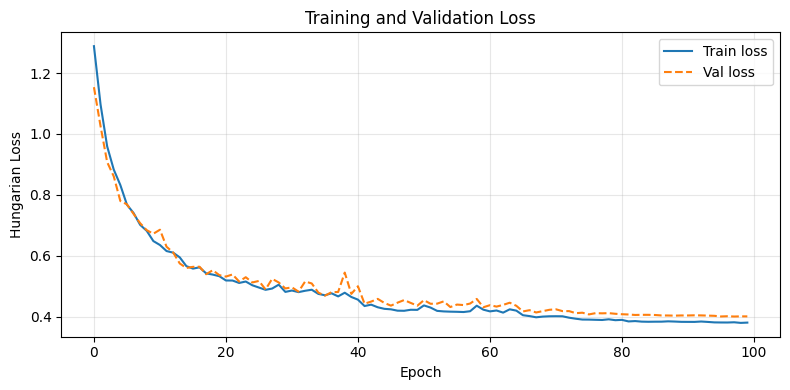

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss',   linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Hungarian Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Test-Set Evaluation

In [42]:
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Hungarian loss: {test_loss:.4f}')

Test Hungarian loss: 0.3889


### IoU Metric

For each ground-truth box we find the predicted box with the highest IoU
(best-match strategy).  The per-image score is the mean of these best-match IoUs.

In [43]:
def box_iou(b1, b2):
    """IoU between two normalised [cx, cy, w, h] boxes (centre format)."""
    cx1, cy1, w1, h1 = b1
    cx2, cy2, w2, h2 = b2
    # convert to corner format for intersection calculation
    x1, y1 = cx1 - w1 / 2, cy1 - h1 / 2
    x2, y2 = cx2 - w2 / 2, cy2 - h2 / 2
    ix1 = max(x1, x2);           iy1 = max(y1, y2)
    ix2 = min(x1 + w1, x2 + w2); iy2 = min(y1 + h1, y2 + h2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0.0


def best_match_iou(gt_boxes, pred_boxes):
    """Mean over actual GT boxes of the best-matching predicted IoU.

    Zero-padded label slots (w == 0) are excluded from evaluation.
    """
    actual = [b for b in gt_boxes if b[2] > 0]
    if not actual:
        return 0.0
    return np.mean([
        max(box_iou(gt, pr) for pr in pred_boxes)
        for gt in actual
    ])


y_pred = model.predict(X_test, verbose=0)
ious   = [best_match_iou(y_test[i], y_pred[i]) for i in range(len(X_test))]

print(f'Mean IoU on test set : {np.mean(ious):.3f}')
print(f'Median IoU           : {np.median(ious):.3f}')
print(f'IoU >= 0.5  (%)      : {100 * np.mean(np.array(ious) >= 0.5):.1f} %')

Mean IoU on test set : 0.940
Median IoU           : 0.955
IoU >= 0.5  (%)      : 99.8 %


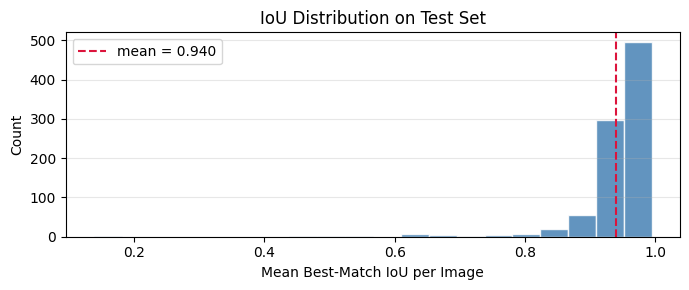

In [44]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ious, bins=20, edgecolor='white', color='steelblue', alpha=0.85)
ax.axvline(np.mean(ious), color='crimson', linestyle='--',
           label=f'mean = {np.mean(ious):.3f}')
ax.set_xlabel('Mean Best-Match IoU per Image')
ax.set_ylabel('Count')
ax.set_title('IoU Distribution on Test Set')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Visual Comparison

**Green** = ground truth  |  **Red dashed** = predicted

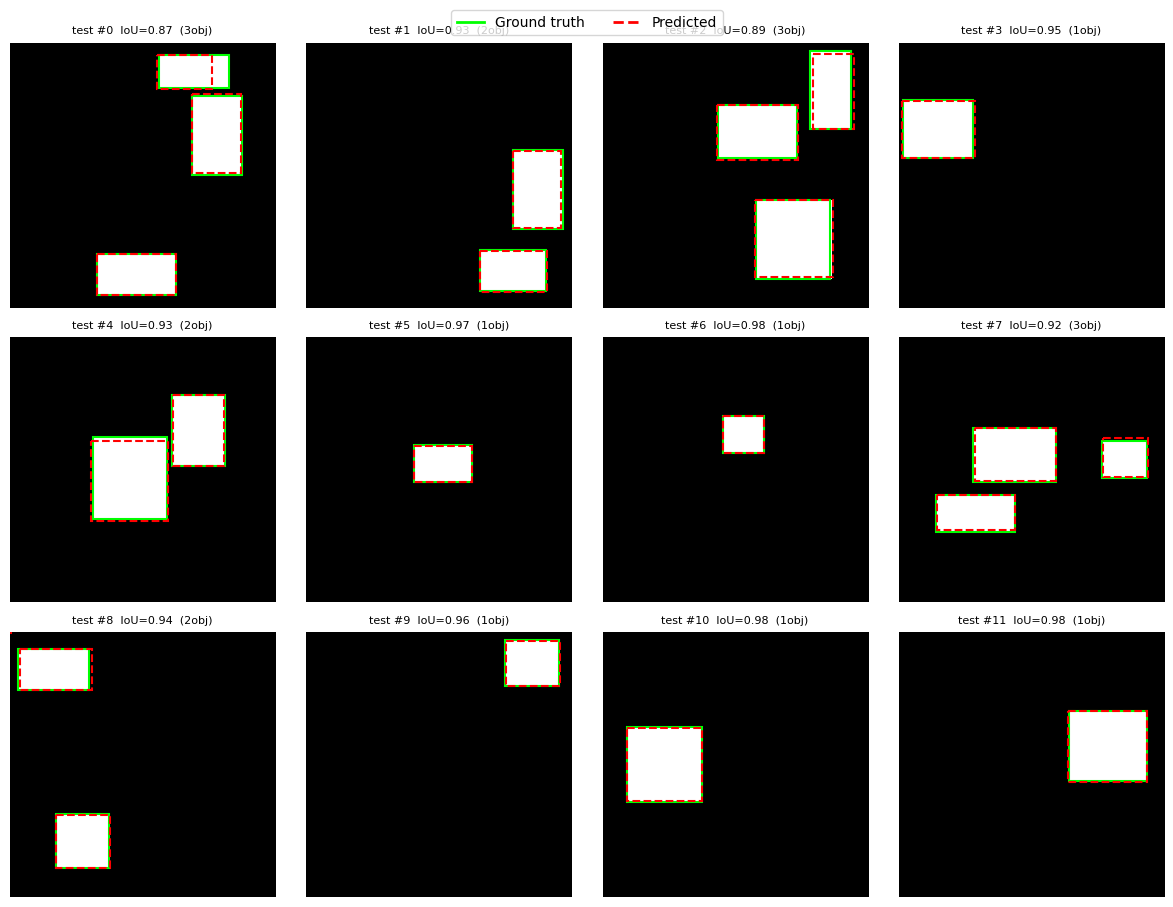

In [45]:
from matplotlib.lines import Line2D


def _to_corner(cx, cy, w, h, img_size):
    """Convert centre [cx,cy,w,h] (normalised) to pixel corner (x,y,w,h).

    Subtracts 0.5 to account for matplotlib's pixel-centre convention:
    imshow centres pixel [r,c] at coordinate (c, r), so a numpy slice
    x:x+w occupies (x-0.5) … (x+w-0.5) in data coordinates.
    """
    px = (cx - w / 2) * img_size - 0.5
    py = (cy - h / 2) * img_size - 0.5
    return px, py, w * img_size, h * img_size


def draw_boxes(ax, image, gt_boxes, pred_boxes=None, img_size=64, title=''):
    ax.imshow(image[:, :, 0], cmap='gray', vmin=0, vmax=1)
    for cx, cy, w, h in gt_boxes:
        if w == 0:          # skip zero-padded slots
            continue
        px, py, pw, ph = _to_corner(cx, cy, w, h, img_size)
        ax.add_patch(patches.Rectangle(
            (px, py), pw, ph,
            linewidth=1.5, edgecolor='lime', facecolor='none'
        ))
    if pred_boxes is not None:
        for cx, cy, w, h in pred_boxes:
            px, py, pw, ph = _to_corner(cx, cy, w, h, img_size)
            ax.add_patch(patches.Rectangle(
                (px, py), pw, ph,
                linewidth=1.5, edgecolor='red', facecolor='none', linestyle='--'
            ))
    ax.set_title(title, fontsize=8)
    ax.axis('off')


n_show = min(12, len(X_test))
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue
    iou_i = best_match_iou(y_test[i], y_pred[i])
    n_actual = int((y_test[i][:, 2] > 0).sum())
    draw_boxes(ax, X_test[i], y_test[i], pred_boxes=y_pred[i],
               title=f'test #{i}  IoU={iou_i:.2f}  ({n_actual}obj)')

legend_handles = [
    Line2D([0], [0], color='lime', linewidth=2, label='Ground truth'),
    Line2D([0], [0], color='red',  linewidth=2, linestyle='--', label='Predicted'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.01), fontsize=10)
plt.tight_layout()
plt.show()